In [1]:
import subprocess
import sys
# PyTorch + plots (torchdiffeq se importa desde la carpeta del repo; ver siguiente celda)
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "torch", "matplotlib", "scipy", "scikit-learn", "pillow"]
)

0

In [2]:
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
if str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))

import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchdiffeq import odeint

torch.manual_seed(0)
np.random.seed(0)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


RK4 NumPy x(tf) = 0.110002
odeint rk4     x(tf) = 0.110002
|Δ| en frontera final (solo x) = 2.06e-09


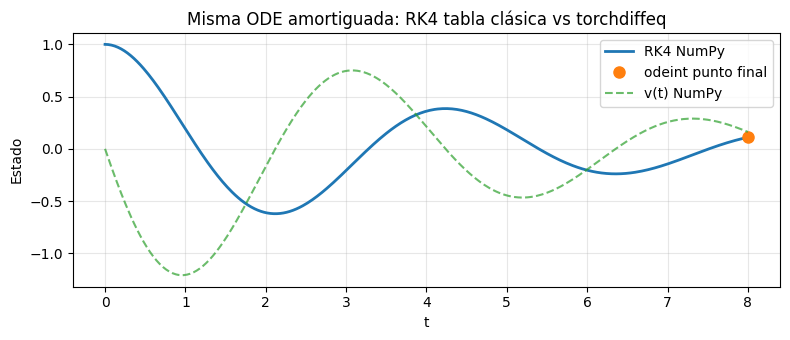

In [3]:
class DampedOscillatorRHS(nn.Module):
    """
    Estado y = [x, v]^T : x' = v, v' = -2ζω₀ v - ω₀² x.
    Es el problema lineal amortiguado 2º orden en forma estándar (la misma física detrás de patrones amortiguados en datos).
    """

    def __init__(self, omega0=1.5, zeta=0.15):
        super().__init__()
        self.register_buffer("omega0", torch.tensor(float(omega0)))
        self.register_buffer("zeta", torch.tensor(float(zeta)))

    def forward(self, t, y):
        x, v = y[..., 0:1], y[..., 1:2]
        w0 = self.omega0
        z = self.zeta
        dvdt = -(2 * z * w0 * v + (w0**2) * x)
        return torch.cat([v, dvdt], dim=-1)


def rk4_fixed_numpy(f_numpy, y0, t0, tf, h):
    """RK4 clásico (vector estado) usando solo NumPy para el librete matemático."""
    y = np.asarray(y0, dtype=np.float64).copy()
    t = float(t0)
    ts = [t]
    ys = [y.copy()]
    while t + 1e-14 < tf:
        dt = min(h, tf - t)
        k1 = f_numpy(t, y)
        k2 = f_numpy(t + 0.5 * dt, y + 0.5 * dt * k1)
        k3 = f_numpy(t + 0.5 * dt, y + 0.5 * dt * k2)
        k4 = f_numpy(t + dt, y + dt * k3)
        y = y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        t += dt
        ts.append(t)
        ys.append(y.copy())
    return np.array(ts), np.stack(ys, axis=0)


def f_np(t, y):
    x, v = y[0], y[1]
    omega0, zeta = 1.5, 0.15
    return np.array([v, -2 * zeta * omega0 * v - (omega0**2) * x], dtype=np.float64)


y0_np = np.array([1.0, 0.0], dtype=np.float64)
h = 0.02
t0, tf = 0.0, 8.0
ts_np, ys_np = rk4_fixed_numpy(f_np, y0_np, t0, tf, h)

func = DampedOscillatorRHS(omega0=1.5, zeta=0.15).to(device)
y0_t = torch.tensor([[1.0, 0.0]], device=device, dtype=torch.float32)
t_line = torch.tensor([t0, tf], device=device, dtype=torch.float32)
with torch.no_grad():
    y_torch = odeint(
        func,
        y0_t,
        t_line,
        method="rk4",
        options={"step_size": h},
    )

x_np = ys_np[:, 0]
x_end_np = x_np[-1]
x_end_torch = y_torch[-1, 0, 0].item()
err = abs(x_end_np - x_end_torch)
print(f"RK4 NumPy x(tf) = {x_end_np:.6f}")
print(f"odeint rk4     x(tf) = {x_end_torch:.6f}")
print(f"|Δ| en frontera final (solo x) = {err:.2e}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ts_np, x_np, label="RK4 NumPy", lw=2)
ax.plot(ts_np[-1], x_end_torch, "o", ms=8, label="odeint punto final")
ax.plot(ts_np, ys_np[:, 1], ls="--", alpha=0.7, label="v(t) NumPy")
ax.set_xlabel("t")
ax.set_ylabel("Estado")
ax.legend()
ax.grid(alpha=0.3)
ax.set_title("Misma ODE amortiguada: RK4 tabla clásica vs torchdiffeq")
plt.tight_layout()
plt.show()


## 1. Generar el dataset



In [4]:
OMEGAS = [1.0, 1.5, 2.0, 2.5, 3.0]
N_CLASSES = len(OMEGAS)
K_MIN, K_MAX = 3, 6
T_MAX = 5.0
N_TRAIN, N_TEST = 8000, 1600
NOISE = 0.09


def generate(n, k_min=K_MIN, k_max=K_MAX, t_max=T_MAX, noise=NOISE):
    t = np.zeros((n, k_max), dtype=np.float32)
    x = np.zeros((n, k_max), dtype=np.float32)
    mask = np.zeros((n, k_max), dtype=np.float32)
    lengths = np.zeros(n, dtype=np.int64)
    y = np.zeros(n, dtype=np.int64)
    for i in range(n):
        c = np.random.randint(0, N_CLASSES)
        omega = OMEGAS[c]
        phi = np.asarray(np.random.uniform(0.0, 2.0 * np.pi), dtype=np.float32)
        K = np.random.randint(k_min, k_max + 1)
        ti = np.sort(np.random.uniform(0, t_max, K).astype(np.float32))
        xi = np.sin(omega * ti + phi) + noise * np.random.randn(K).astype(np.float32)
        t[i, :K] = ti
        x[i, :K] = xi
        mask[i, :K] = 1.0
        lengths[i] = K
        y[i] = c
    return (
        torch.tensor(t),
        torch.tensor(x),
        torch.tensor(mask),
        torch.tensor(lengths),
        torch.tensor(y),
    )


t_tr, x_tr, m_tr, len_tr, y_tr = (a.to(device) for a in generate(N_TRAIN))
t_te, x_te, m_te, len_te, y_te = (a.to(device) for a in generate(N_TEST))
print(f"Train {len(t_tr)} | Test {len(t_te)} | K={K_MIN}..{K_MAX} | noise={NOISE} | ω={OMEGAS}")


Train 8000 | Test 1600 | K=3..6 | noise=0.09 | ω=[1.0, 1.5, 2.0, 2.5, 3.0]


### Ver datos


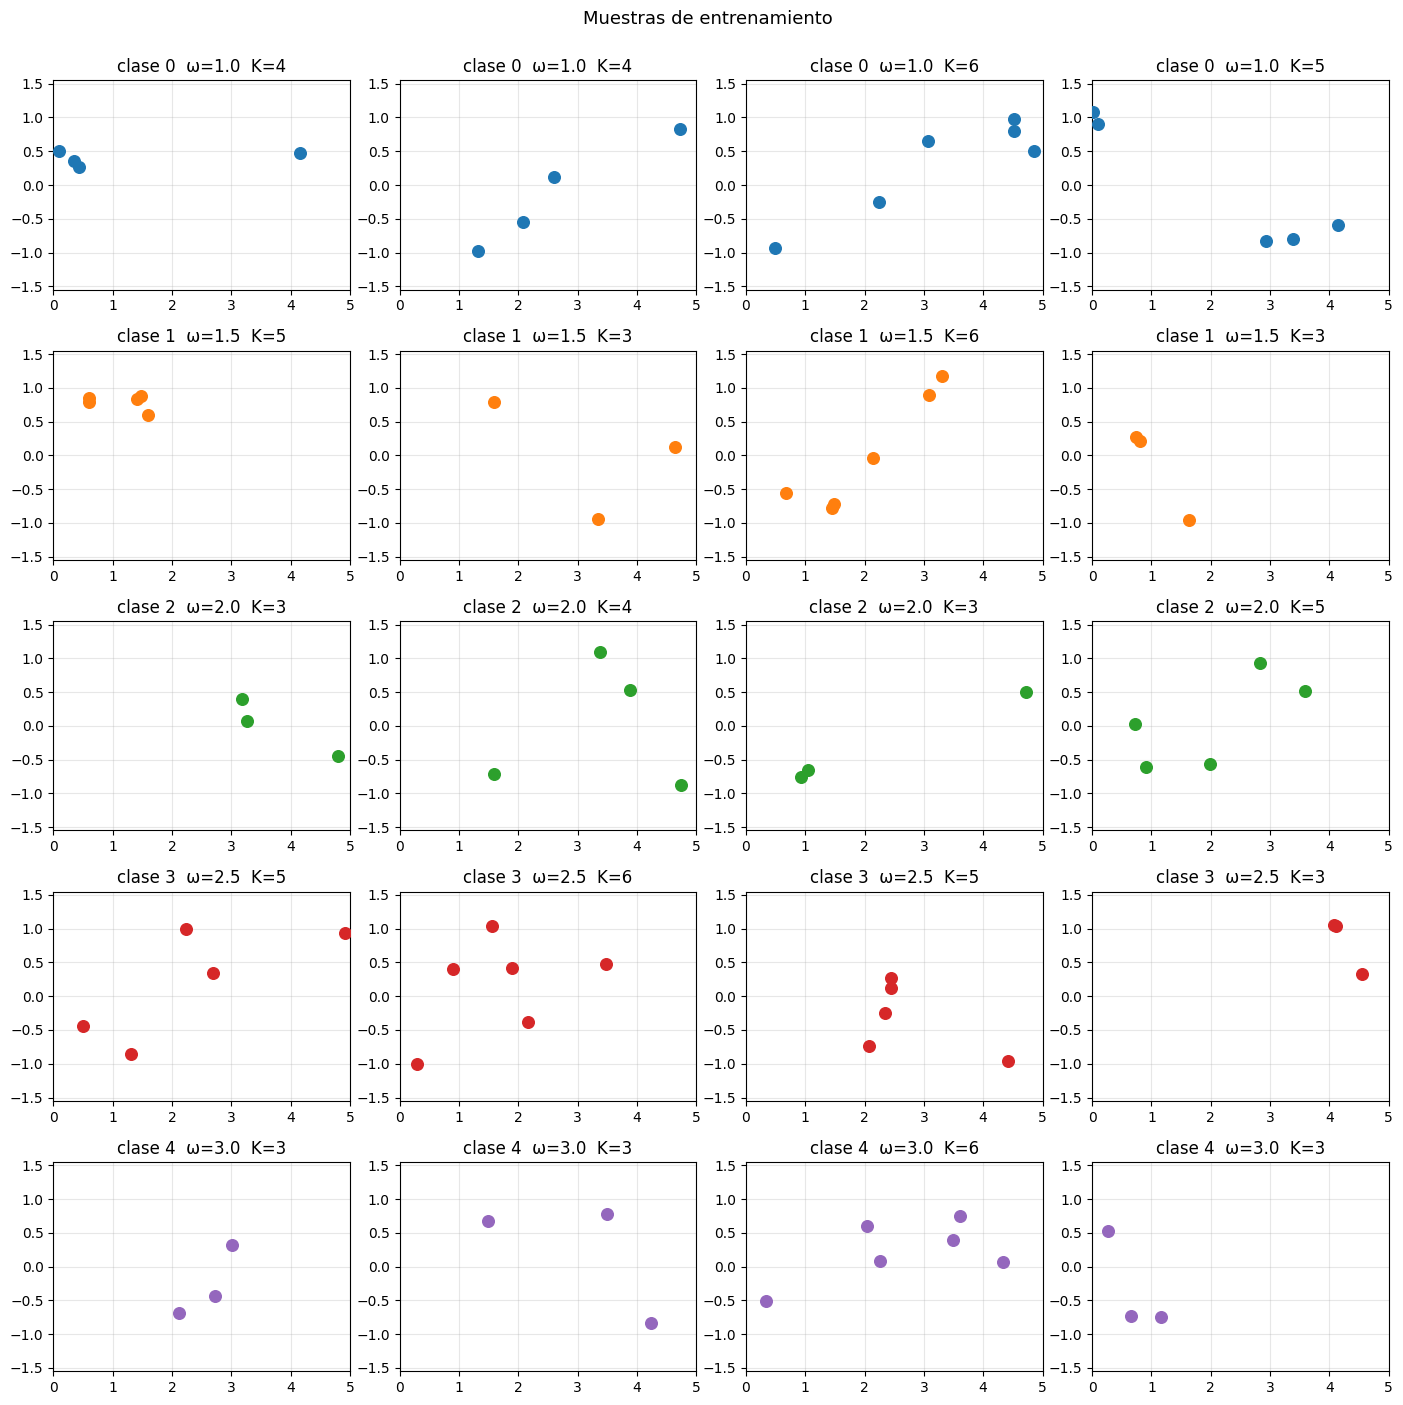

In [5]:
fig, axes = plt.subplots(N_CLASSES, 4, figsize=(14, 2.8 * N_CLASSES))
if N_CLASSES == 1:
    axes = np.expand_dims(axes, 0)
for c in range(N_CLASSES):
    idxs = (y_tr == c).nonzero(as_tuple=True)[0][:4]
    for j, idx in enumerate(idxs):
        L = len_tr[idx].item()
        ax = axes[c, j]
        ax.scatter(t_tr[idx, :L].cpu(), x_tr[idx, :L].cpu(), s=70, color="C" + str(c), zorder=3)
        ax.set_title(f"clase {c}  ω={OMEGAS[c]}  K={L}")
        ax.set_ylim(-1.55, 1.55)
        ax.set_xlim(0, T_MAX)
        ax.grid(alpha=0.3)
plt.suptitle("Muestras de entrenamiento", y=1.0, fontsize=13)
plt.tight_layout()
plt.show()


## 2. Tres modelos para comparar

### Modelo 1: MLP 

Recibe (t, x, mask) apilados hasta `K_MAX` (**3·K_max** valores). No tiene noción de **tiempo** como continuo.

In [6]:
class MLPClassifier(nn.Module):
    def __init__(self, K=K_MAX, n_classes=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3 * K, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes),
        )

    def forward(self, t, x, mask, lengths):
        return self.net(torch.cat([t, x, mask], dim=1))


### Modelo 2: GRU 

Procesa los puntos secuencialmente. Sabe que es una secuencia, pero **no usa los tiempos como tiempos**, solo como features más.

In [7]:
class GRUClassifier(nn.Module):
    def __init__(self, latent=32, n_classes=N_CLASSES):
        super().__init__()
        self.enc = nn.GRU(
            input_size=2,
            hidden_size=latent,
            batch_first=True,
            num_layers=2,
            dropout=0.1,
        )
        self.clf = nn.Sequential(nn.Linear(latent, 32), nn.ReLU(), nn.Linear(32, n_classes))

    def forward(self, t, x, mask, lengths):
        inp = torch.stack([t, x], dim=-1)
        packed = nn.utils.rnn.pack_padded_sequence(
            inp, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, h = self.enc(packed)
        return self.clf(h[-1])


### Modelo 3: ODE-RNN — 
para batch con dt distintos por ejemplo, en vez de hacer `odeint` con tiempos diferentes (no se puede vectorizar), reescalamos la dinámica: `dh/ds = dt · f(h)` con `s ∈ [0,1]` equivale a integrar `f` durante tiempo real `dt`. Eso sí se vectoriza.

In [8]:
class ODEFunc(nn.Module):
    def __init__(self, dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, dim),
        )

    def forward(self, t, z):
        return self.net(z)


class ODERNN(nn.Module):
    """ODE entre observaciones + GRUCell."""

    def __init__(self, latent=32, n_classes=N_CLASSES):
        super().__init__()
        self.latent = latent
        self.ode_func = ODEFunc(latent)
        self.gru_cell = nn.GRUCell(input_size=1, hidden_size=latent)
        self.clf = nn.Sequential(nn.Linear(latent, 32), nn.ReLU(), nn.Linear(32, n_classes))
        self.register_buffer("t01", torch.tensor([0.0, 1.0]))

    def evolve(self, h, dt):
        dt_e = dt.unsqueeze(-1)

        def scaled_ode(s, h):
            return dt_e * self.ode_func(s, h)

        return odeint(
            scaled_ode,
            h,
            self.t01,
            method="rk4",
            options={"step_size": 0.25},
        )[-1]

    def forward(self, t, x, mask, lengths):
        B, K = t.shape
        h = torch.zeros(B, self.latent, device=t.device)
        t_prev = torch.zeros(B, device=t.device)
        for i in range(K):
            active = mask[:, i].bool()
            if not active.any():
                break
            dt = (t[:, i] - t_prev).clamp(min=1e-6)
            h_evolved = self.evolve(h, dt)
            h_updated = self.gru_cell(x[:, i : i + 1], h_evolved)
            h = torch.where(active.unsqueeze(-1), h_updated, h_evolved)
            t_prev = torch.where(active, t[:, i], t_prev)
        return self.clf(h)

    @torch.no_grad()
    def encode_final(self, t, x, mask, lengths):
        """Estado oculto final (B, latent) sin cabeza de clasificación."""
        self.eval()
        B, K = t.shape
        h = torch.zeros(B, self.latent, device=t.device)
        t_prev = torch.zeros(B, device=t.device)
        for i in range(K):
            active = mask[:, i].bool()
            if not active.any():
                break
            dt = (t[:, i] - t_prev).clamp(min=1e-6)
            h_evolved = self.evolve(h, dt)
            h_updated = self.gru_cell(x[:, i : i + 1], h_evolved)
            h = torch.where(active.unsqueeze(-1), h_updated, h_evolved)
            t_prev = torch.where(active, t[:, i], t_prev)
        return h

    @torch.no_grad()
    def trace_single(self, t, x, mask, length):
        """Una secuencia (batch 1). Devuelve tiempos, h tras cada obs, logits tras cada obs."""
        self.eval()
        Lseq = int(length.item()) if hasattr(length, "item") else int(length)
        t = t[0]
        x = x[0]
        mask = mask[0]
        h = torch.zeros(self.latent, device=t.device)
        t_prev = torch.zeros((), device=t.device)
        times, hs, logits = [], [], []
        for i in range(t.shape[0]):
            if i >= Lseq:
                break
            if mask[i] <= 0:
                break
            dt = (t[i] - t_prev).clamp(min=1e-6)
            h_ev = self.evolve(h.unsqueeze(0), dt.unsqueeze(0)).squeeze(0)
            h = self.gru_cell(x[i : i + 1], h_ev)
            t_prev = t[i]
            times.append(t[i])
            hs.append(h.clone())
            logits.append(self.clf(h).squeeze(0).clone())
        return torch.stack(times), torch.stack(hs, dim=0), torch.stack(logits, dim=0)


## 3. Entrenar

MLP y GRU con **más épocas** y LR un poco más alto; el **ODE-RNN** usa menos épocas por coste por paso pero suficientes para converger en test. Se registra **loss** media de entrenamiento por época para graficar.


In [9]:
def train(model, epochs, lr, batch, log_every=20, name=""):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = len(y_tr)
    t0 = time.time()
    history = {"ep": [], "train": [], "test": [], "loss": []}
    best = 0.0
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        loss_acc = 0.0
        n_batches = 0
        for i in range(0, n, batch):
            idx = perm[i : i + batch]
            opt.zero_grad(set_to_none=True)
            logits = model(t_tr[idx], x_tr[idx], m_tr[idx], len_tr[idx])
            loss = F.cross_entropy(logits, y_tr[idx])
            loss.backward()
            opt.step()
            loss_acc += loss.detach().item()
            n_batches += 1
        mean_loss = loss_acc / max(n_batches, 1)
        if ep % 5 == 0 or ep == epochs - 1:
            model.eval()
            with torch.no_grad():
                tr = (
                    model(t_tr, x_tr, m_tr, len_tr).argmax(1) == y_tr
                ).float().mean().item()
                te = (
                    model(t_te, x_te, m_te, len_te).argmax(1) == y_te
                ).float().mean().item()
                history["ep"].append(ep)
                history["train"].append(tr)
                history["test"].append(te)
                history["loss"].append(mean_loss)
                best = max(best, te)
            if ep % log_every == 0 or ep == epochs - 1:
                print(
                    f"[{name}] ep {ep:4d}  train={tr:.3f}  test={te:.3f}  loss={mean_loss:.4f}"
                )
    history["time"] = time.time() - t0
    history["best"] = best
    print(f"[{name}] {history['time']:.1f}s  best_test={best:.3f}\n")
    return history


In [10]:
print(">>> MLP")
mlp = MLPClassifier().to(device)
print(f"params: {sum(p.numel() for p in mlp.parameters())}")
hist_mlp = train(mlp, epochs=260, lr=3e-3, batch=256, log_every=25, name="MLP")


>>> MLP
params: 27525
[MLP] ep    0  train=0.227  test=0.242  loss=1.6109
[MLP] ep   25  train=0.680  test=0.586  loss=0.8248
[MLP] ep   50  train=0.795  test=0.577  loss=0.5633
[MLP] ep   75  train=0.864  test=0.584  loss=0.4132
[MLP] ep  100  train=0.903  test=0.577  loss=0.2915
[MLP] ep  125  train=0.910  test=0.581  loss=0.2775
[MLP] ep  150  train=0.937  test=0.572  loss=0.1961
[MLP] ep  175  train=0.960  test=0.579  loss=0.1321
[MLP] ep  200  train=0.980  test=0.572  loss=0.0952
[MLP] ep  225  train=0.989  test=0.577  loss=0.0682
[MLP] ep  250  train=0.989  test=0.573  loss=0.0587
[MLP] ep  259  train=0.974  test=0.568  loss=0.0674
[MLP] 7.8s  best_test=0.589



In [11]:
print(">>> GRU")
gru = GRUClassifier().to(device)
print(f"params: {sum(p.numel() for p in gru.parameters())}")
hist_gru = train(gru, epochs=260, lr=3e-3, batch=256, log_every=25, name="GRU")


>>> GRU
params: 11013
[GRU] ep    0  train=0.209  test=0.212  loss=1.6110
[GRU] ep   25  train=0.601  test=0.570  loss=0.9998
[GRU] ep   50  train=0.715  test=0.637  loss=0.7590
[GRU] ep   75  train=0.775  test=0.666  loss=0.6512
[GRU] ep  100  train=0.811  test=0.673  loss=0.5771
[GRU] ep  125  train=0.838  test=0.671  loss=0.5255
[GRU] ep  150  train=0.859  test=0.673  loss=0.4816
[GRU] ep  175  train=0.882  test=0.694  loss=0.4592
[GRU] ep  200  train=0.893  test=0.686  loss=0.4252
[GRU] ep  225  train=0.883  test=0.666  loss=0.4165
[GRU] ep  250  train=0.920  test=0.683  loss=0.3952
[GRU] ep  259  train=0.921  test=0.677  loss=0.3829
[GRU] 14.9s  best_test=0.694



In [12]:
print(">>> ODE-RNN")
ode = ODERNN().to(device)
print(f"params: {sum(p.numel() for p in ode.parameters())}")
hist_ode = train(ode, epochs=200, lr=2.5e-3, batch=192, log_every=25, name="ODE-RNN")


>>> ODE-RNN
params: 12933
[ODE-RNN] ep    0  train=0.206  test=0.197  loss=1.6101
[ODE-RNN] ep   25  train=0.760  test=0.724  loss=0.5952
[ODE-RNN] ep   50  train=0.826  test=0.749  loss=0.4093
[ODE-RNN] ep   75  train=0.884  test=0.774  loss=0.3049
[ODE-RNN] ep  100  train=0.915  test=0.772  loss=0.2565
[ODE-RNN] ep  125  train=0.930  test=0.761  loss=0.1926
[ODE-RNN] ep  150  train=0.928  test=0.769  loss=0.1791
[ODE-RNN] ep  175  train=0.964  test=0.768  loss=0.1420
[ODE-RNN] ep  199  train=0.973  test=0.768  loss=0.0903
[ODE-RNN] 415.7s  best_test=0.783





## 4. Salidas

1. **Curvas de entrenamiento:** *accuracy* train/test por época y **loss** (entropía cruzada media por época en train) para MLP, GRU y ODE-RNN → se guardan y muestran en **`figures/01_curvas_acc_loss.png`**.
2. **Resumen numérico:** mejor test y tiempo → **`figures/02_barras_best_tiempo.png`**.



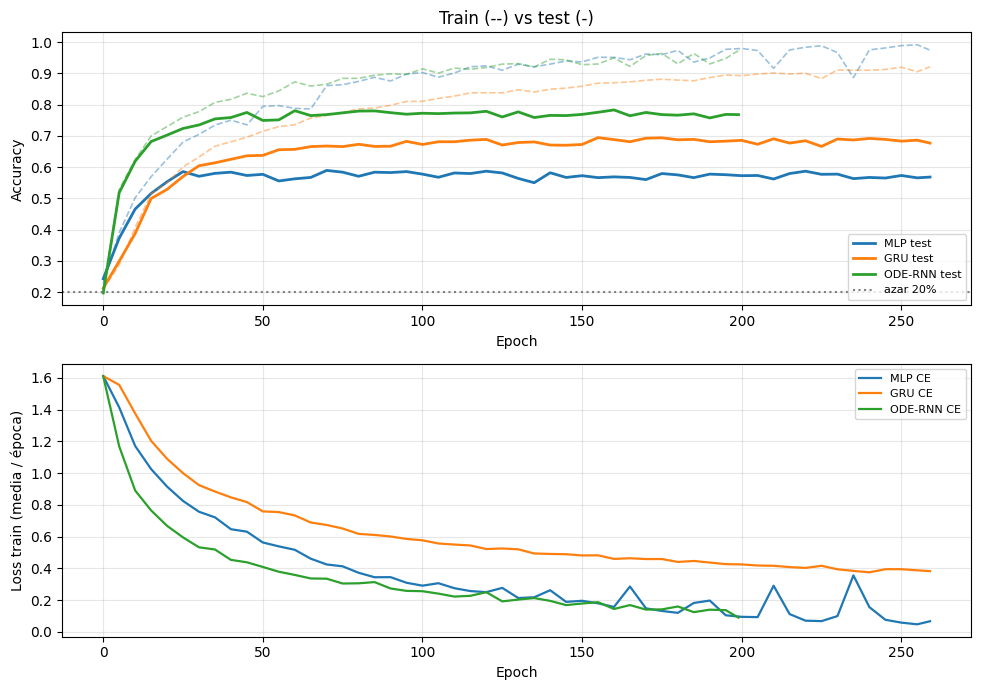

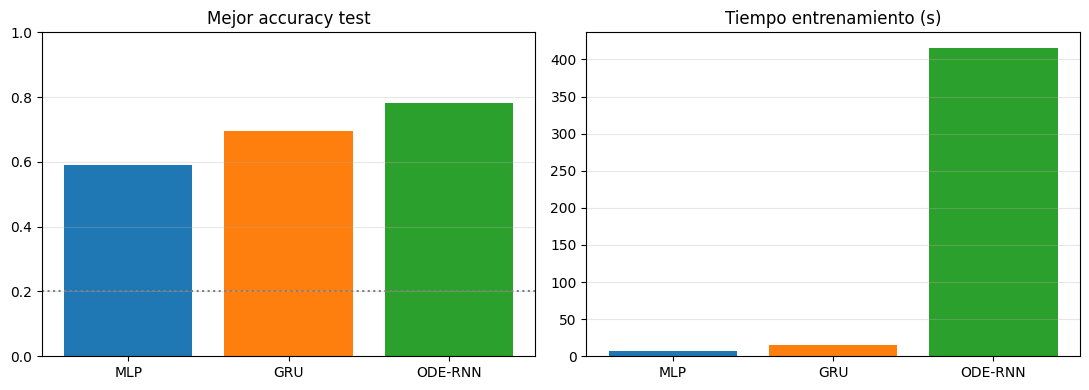

Figuras: /home/juan/Downloads/torchdiffeq-master/figures


In [16]:
from pathlib import Path

FIG = Path("figures")
FIG.mkdir(exist_ok=True)

chance = 1.0 / N_CLASSES
series = [
    (hist_mlp, "C0", "MLP"),
    (hist_gru, "C1", "GRU"),
    (hist_ode, "C2", "ODE-RNN"),
]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)
for hist, color, lab in series:
    axes[0].plot(hist["ep"], hist["train"], "--", color=color, alpha=0.45, lw=1.2)
    axes[0].plot(hist["ep"], hist["test"], "-", color=color, label=lab + " test", lw=2)
axes[0].axhline(chance, ls=":", color="gray", label=f"azar {100*chance:.0f}%")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Train (--) vs test (-)")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(alpha=0.3)

for hist, color, lab in series:
    axes[1].plot(hist["ep"], hist["loss"], "-", color=color, label=lab + " CE", lw=1.6)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss train (media / época)")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG / "01_curvas_acc_loss.png", dpi=160)
plt.show()

fig2, axb = plt.subplots(1, 2, figsize=(11, 4))
names = ["MLP", "GRU", "ODE-RNN"]
bests = [hist_mlp["best"], hist_gru["best"], hist_ode["best"]]
times = [hist_mlp["time"], hist_gru["time"], hist_ode["time"]]
cols = ["C0", "C1", "C2"]
axb[0].bar(names, bests, color=cols)
axb[0].axhline(chance, color="gray", ls=":")
axb[0].set_ylim(0, 1)
axb[0].set_title("Mejor accuracy test")
axb[0].grid(axis="y", alpha=0.3)
axb[1].bar(names, times, color=cols)
axb[1].set_title("Tiempo entrenamiento (s)")
axb[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "02_barras_best_tiempo.png", dpi=160)
plt.show()


print("Figuras:", FIG.resolve())
